# ASTR-154 Final Project - Exoplanet Obliquity Angle
## File: hypothesis_testing
This file contains to code for performing hypothesis testing on two sets of obliquity angle data in order to determine whether they belong to different distributions based on the obliquity angle value and their systems "binarity"
Author: Babak Aryan

In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read in the Exoplanet data generated from the "NASA Exoplanet Archive" database
file_loc = '../data/'
file_name = 'NASA-Exoplanet-Archive-20260514.csv'
exo_table = Table.read(file_loc+file_name, format='ascii.csv', header_start=123)

In [13]:
binary_sys = exo_table[exo_table['sy_snum'] >  1]['discoverymethod', 'sy_snum', 'pl_projobliq']
single_sys = exo_table[exo_table['sy_snum'] == 1]['discoverymethod', 'sy_snum', 'pl_projobliq']
print(binary_sys, '\n')
print(single_sys, '\n')


discoverymethod sy_snum pl_projobliq
--------------- ------- ------------
        Transit       2          4.0
        Transit       2        -1.47
        Transit       2          3.7
        Transit       2        189.1
        Transit       3        -10.0
        Transit       2         -2.1
        Transit       2         20.0
        Transit       2         24.2
        Transit       2        -26.0
        Transit       2         21.2
            ...     ...          ...
        Transit       2        251.2
        Transit       2         54.0
        Transit       2         64.6
        Transit       2        61.28
        Transit       2       -143.0
        Transit       2       -143.0
        Transit       2         14.0
        Transit       2         -8.0
        Transit       2        151.0
        Transit       2          7.0
Length = 76 rows 

discoverymethod sy_snum pl_projobliq
--------------- ------- ------------
        Transit       1         -4.7
        Transit    

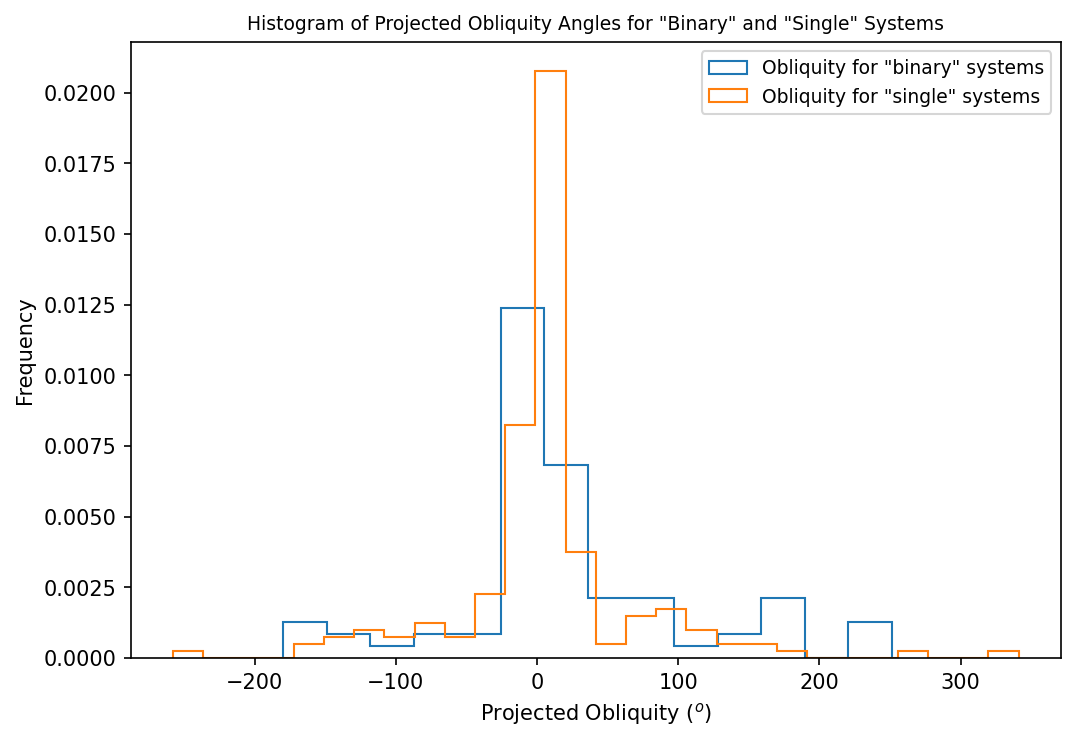

In [32]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the normally distributed random values
plt.hist(binary_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['Obliquity for "binary" systems', 'Obliquity for "single" systems'], fontsize=9, loc=1);

plt.show()

In [24]:
from scipy import stats

In [27]:
# Calculating D and p-value for the 2-sample K-S test
ks_d, ks_p = stats.kstest(binary_sys['pl_projobliq'], single_sys['pl_projobliq'])
print(f'K-S D, p-value: {ks_d:0.4f} {ks_p:0.4%}')

K-S D, p-value: 0.1480 16.5913%


In [25]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
ad = stats.anderson_ksamp([binary_sys['pl_projobliq'], single_sys['pl_projobliq']], variant='midrank', method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad.statistic:0.4f} {ad.pvalue:0.4%}')


A-D statistics and p-value: 1.4780 8.1200%
